# Baseline Solution Testing

This notebook tests the provided baseline solution and explores simple prediction strategies to establish performance benchmarks.

## Baseline Strategies to Test:
1. **Moving Average** (provided example)
2. **Last Value Persistence** (naive forecast)
3. **Exponential Moving Average**
4. **Linear Extrapolation**

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add competition package to path
sys.path.append('../competition_package')
from utils import DataPoint, ScorerStepByStep

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Test Provided Moving Average Baseline

In [2]:
# Load the example solution
sys.path.append('../competition_package/examples/simple')
from solution import PredictionModel as MovingAverageModel

# Initialize scorer
data_path = '../competition_package/datasets/train.parquet'
scorer = ScorerStepByStep(data_path)

print(f"Dataset: {len(scorer.dataset):,} rows")
print(f"Features: {scorer.dim}")

Dataset: 517,000 rows
Features: 32


In [3]:
# Test moving average model
print("Testing Moving Average Model...\n")
ma_model = MovingAverageModel()
ma_results = scorer.score(ma_model)

print("\n" + "="*70)
print("MOVING AVERAGE RESULTS")
print("="*70)
print(f"Mean R²: {ma_results['mean_r2']:.6f}")
print(f"\nR² by feature (first 10):")
for i, feature in enumerate(scorer.features[:10]):
    print(f"  {feature}: {ma_results[feature]:>10.6f}")

Testing Moving Average Model...



  0%|          | 0/517000 [00:00<?, ?it/s]


MOVING AVERAGE RESULTS
Mean R²: 0.221986

R² by feature (first 10):
  0:   0.073986
  1:   0.096358
  2:   0.242396
  3:   0.346401
  4:   0.169095
  5:   0.102665
  6:   0.363337
  7:   0.384533
  8:   0.344983
  9:   0.185628


## 2. Last Value Persistence (Naive Forecast)

In [4]:
class LastValueModel:
    """
    Predict next value as the current value (persistence/random walk model).
    This is the simplest possible forecast.
    """
    def __init__(self):
        self.current_seq_ix = None
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        # Reset on new sequence
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
        
        if not data_point.need_prediction:
            return None
        
        # Predict: next value = current value
        return data_point.state.copy()

In [5]:
# Test last value model
print("Testing Last Value Persistence Model...\n")
lv_model = LastValueModel()
lv_results = scorer.score(lv_model)

print("\n" + "="*70)
print("LAST VALUE PERSISTENCE RESULTS")
print("="*70)
print(f"Mean R²: {lv_results['mean_r2']:.6f}")
print(f"\nR² by feature (first 10):")
for i, feature in enumerate(scorer.features[:10]):
    print(f"  {feature}: {lv_results[feature]:>10.6f}")

Testing Last Value Persistence Model...



  0%|          | 0/517000 [00:00<?, ?it/s]


LAST VALUE PERSISTENCE RESULTS
Mean R²: -0.389050

R² by feature (first 10):
  0:  -0.415507
  1:  -0.564121
  2:  -0.096538
  3:  -0.211807
  4:  -0.649228
  5:  -0.538803
  6:  -0.370354
  7:   0.033955
  8:  -0.215801
  9:  -0.733174


## 3. Exponential Moving Average

In [6]:
class ExponentialMovingAverageModel:
    """
    Predict using exponential weighted moving average.
    Gives more weight to recent observations.
    """
    def __init__(self, alpha=0.3):
        """
        Args:
            alpha: Smoothing factor (0 to 1). Higher = more weight on recent values.
        """
        self.alpha = alpha
        self.current_seq_ix = None
        self.ema = None
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        # Reset on new sequence
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.ema = None
        
        # Update EMA
        if self.ema is None:
            self.ema = data_point.state.copy()
        else:
            self.ema = self.alpha * data_point.state + (1 - self.alpha) * self.ema
        
        if not data_point.need_prediction:
            return None
        
        return self.ema.copy()

In [7]:
# Test different alpha values
alphas_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
ema_results_all = {}

for alpha in alphas_to_test:
    print(f"Testing EMA with alpha={alpha}...")
    ema_model = ExponentialMovingAverageModel(alpha=alpha)
    results = scorer.score(ema_model)
    ema_results_all[alpha] = results['mean_r2']
    print(f"  Mean R²: {results['mean_r2']:.6f}")

# Find best alpha
best_alpha = max(ema_results_all, key=ema_results_all.get)
print(f"\nBest alpha: {best_alpha} with R² = {ema_results_all[best_alpha]:.6f}")

Testing EMA with alpha=0.1...


  0%|          | 0/517000 [00:00<?, ?it/s]

  Mean R²: 0.253270
Testing EMA with alpha=0.3...


  0%|          | 0/517000 [00:00<?, ?it/s]

  Mean R²: 0.191011
Testing EMA with alpha=0.5...


...

  Mean R²: 0.090670
Testing EMA with alpha=0.7...


  0%|          | 0/517000 [00:00<?, ?it/s]

  Mean R²: -0.051096
Testing EMA with alpha=0.9...


  0%|          | 0/517000 [00:00<?, ?it/s]

  Mean R²: -0.253629

Best alpha: 0.1 with R² = 0.253270


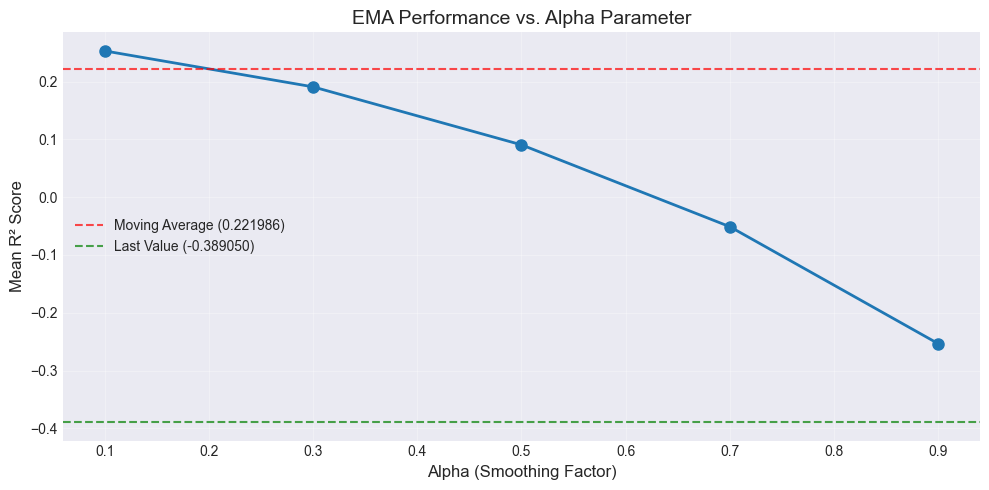

In [8]:
# Plot alpha vs R²
plt.figure(figsize=(10, 5))
plt.plot(list(ema_results_all.keys()), list(ema_results_all.values()), 
         marker='o', linewidth=2, markersize=8)
plt.xlabel('Alpha (Smoothing Factor)', fontsize=12)
plt.ylabel('Mean R² Score', fontsize=12)
plt.title('EMA Performance vs. Alpha Parameter', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=ma_results['mean_r2'], color='red', linestyle='--', 
            label=f'Moving Average ({ma_results["mean_r2"]:.6f})', alpha=0.7)
plt.axhline(y=lv_results['mean_r2'], color='green', linestyle='--', 
            label=f'Last Value ({lv_results["mean_r2"]:.6f})', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Linear Extrapolation

In [9]:
class LinearExtrapolationModel:
    """
    Predict by fitting a linear trend to recent history and extrapolating.
    Uses last N points to estimate trend.
    """
    def __init__(self, window=10):
        """
        Args:
            window: Number of recent points to use for trend estimation
        """
        self.window = window
        self.current_seq_ix = None
        self.history = []
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        # Reset on new sequence
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.history = []
        
        # Add current observation to history
        self.history.append(data_point.state.copy())
        
        if not data_point.need_prediction:
            return None
        
        # Use last 'window' points for trend estimation
        recent_history = np.array(self.history[-self.window:])
        
        if len(recent_history) < 2:
            # Not enough history, just return last value
            return data_point.state.copy()
        
        # Fit linear trend for each feature
        n_points = len(recent_history)
        x = np.arange(n_points)
        predictions = []
        
        for feature_idx in range(recent_history.shape[1]):
            y = recent_history[:, feature_idx]
            # Simple linear regression: y = a + b*x
            coeffs = np.polyfit(x, y, deg=1)
            # Predict next point (x = n_points)
            next_val = coeffs[0] * n_points + coeffs[1]
            predictions.append(next_val)
        
        return np.array(predictions)

In [10]:
# Test different window sizes
windows_to_test = [5, 10, 20, 30, 50]
linear_results_all = {}

for window in windows_to_test:
    print(f"Testing Linear Extrapolation with window={window}...")
    linear_model = LinearExtrapolationModel(window=window)
    results = scorer.score(linear_model)
    linear_results_all[window] = results['mean_r2']
    print(f"  Mean R²: {results['mean_r2']:.6f}")

# Find best window
best_window = max(linear_results_all, key=linear_results_all.get)
print(f"\nBest window: {best_window} with R² = {linear_results_all[best_window]:.6f}")

Testing Linear Extrapolation with window=5...


  0%|          | 0/517000 [00:00<?, ?it/s]

  Mean R²: -0.391393
Testing Linear Extrapolation with window=10...


  0%|          | 0/517000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Plot window size vs R²
plt.figure(figsize=(10, 5))
plt.plot(list(linear_results_all.keys()), list(linear_results_all.values()), 
         marker='s', linewidth=2, markersize=8, color='purple')
plt.xlabel('Window Size', fontsize=12)
plt.ylabel('Mean R² Score', fontsize=12)
plt.title('Linear Extrapolation Performance vs. Window Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=ma_results['mean_r2'], color='red', linestyle='--', 
            label=f'Moving Average ({ma_results["mean_r2"]:.6f})', alpha=0.7)
plt.axhline(y=lv_results['mean_r2'], color='green', linestyle='--', 
            label=f'Last Value ({lv_results["mean_r2"]:.6f})', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Baseline Comparison Summary

In [ ]:
# Create comparison table
baseline_summary = pd.DataFrame([
    {'Model': 'Last Value Persistence', 'Mean R²': lv_results['mean_r2'], 'Config': '-'},
    {'Model': 'Moving Average', 'Mean R²': ma_results['mean_r2'], 'Config': 'all history'},
    {'Model': 'Exponential MA', 'Mean R²': ema_results_all[best_alpha], 'Config': f'alpha={best_alpha}'},
    {'Model': 'Linear Extrapolation', 'Mean R²': linear_results_all[best_window], 'Config': f'window={best_window}'},
]).sort_values('Mean R²', ascending=False)

print("\n" + "="*70)
print("BASELINE MODEL COMPARISON")
print("="*70)
print(baseline_summary.to_string(index=False))
print("\nBest baseline model:", baseline_summary.iloc[0]['Model'])
print(f"Score to beat: {baseline_summary.iloc[0]['Mean R²']:.6f}")

In [ ]:
# Visualize comparison
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.barh(baseline_summary['Model'], baseline_summary['Mean R²'], color=colors)
plt.xlabel('Mean R² Score', fontsize=12)
plt.title('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(baseline_summary.iterrows()):
    plt.text(row['Mean R²'] + 0.001, i, f"{row['Mean R²']:.6f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Per-Feature Performance Analysis

In [ ]:
# Compare performance across features for best baseline
# Re-run best model to get detailed results
best_baseline_name = baseline_summary.iloc[0]['Model']

if best_baseline_name == 'Last Value Persistence':
    best_results = lv_results
elif best_baseline_name == 'Moving Average':
    best_results = ma_results
elif best_baseline_name == 'Exponential MA':
    best_model = ExponentialMovingAverageModel(alpha=best_alpha)
    best_results = scorer.score(best_model)
else:  # Linear Extrapolation
    best_model = LinearExtrapolationModel(window=best_window)
    best_results = scorer.score(best_model)

# Extract per-feature scores
feature_scores = [(feat, best_results[feat]) for feat in scorer.features]
feature_scores_df = pd.DataFrame(feature_scores, columns=['Feature', 'R²'])
feature_scores_df = feature_scores_df.sort_values('R²', ascending=False)

print("\nTop 10 features (highest R²):")
print(feature_scores_df.head(10).to_string(index=False))

print("\nBottom 10 features (lowest R²):")
print(feature_scores_df.tail(10).to_string(index=False))

In [ ]:
# Distribution of R² scores across features
plt.figure(figsize=(12, 5))
plt.hist(feature_scores_df['R²'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=best_results['mean_r2'], color='red', linestyle='--', 
            linewidth=2, label=f'Mean R² = {best_results["mean_r2"]:.6f}')
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title(f'Distribution of R² Scores Across Features ({best_baseline_name})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Insights

**To be filled in after running:**

1. **Best Baseline Model:** [Model name] with R² = [score]

2. **Performance Observations:**
   - Simple persistence vs. smoothing approaches
   - Optimal hyperparameters (alpha, window size)
   - Variance in performance across features

3. **Implications for ML Models:**
   - Target R² to beat
   - Features that are easy/hard to predict
   - Characteristics of predictable patterns

4. **Next Steps:**
   - Feature engineering opportunities
   - Model architecture considerations
   - Training strategies